In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler , StandardScaler
import seaborn as sns
import joblib

In [33]:
data = pd.read_csv(r'heart.csv')

In [34]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [36]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [37]:
data.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [38]:
data.shape

(1025, 14)

In [39]:
data.duplicated().sum()

np.int64(723)

In [40]:
data.drop_duplicates(inplace =True)

In [41]:
data.shape

(302, 14)

In [42]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [43]:
data['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'thalach'}>],
       [<Axes: title={'center': 'oldpeak'}>, <Axes: >]], dtype=object)

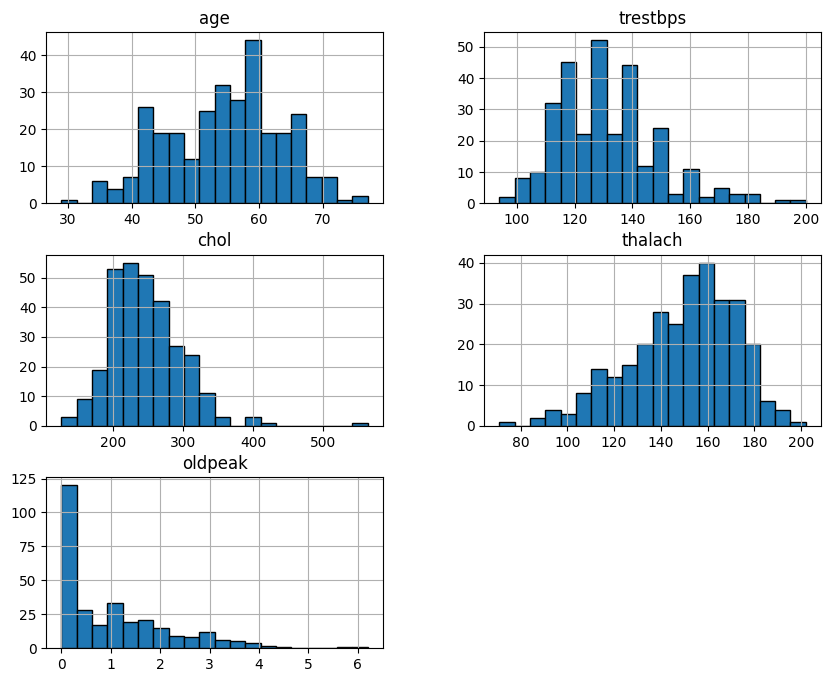

In [44]:
num_cols = ['age','trestbps','chol','thalach','oldpeak']
data[num_cols].hist(bins=20,figsize=(10,8),edgecolor='black')

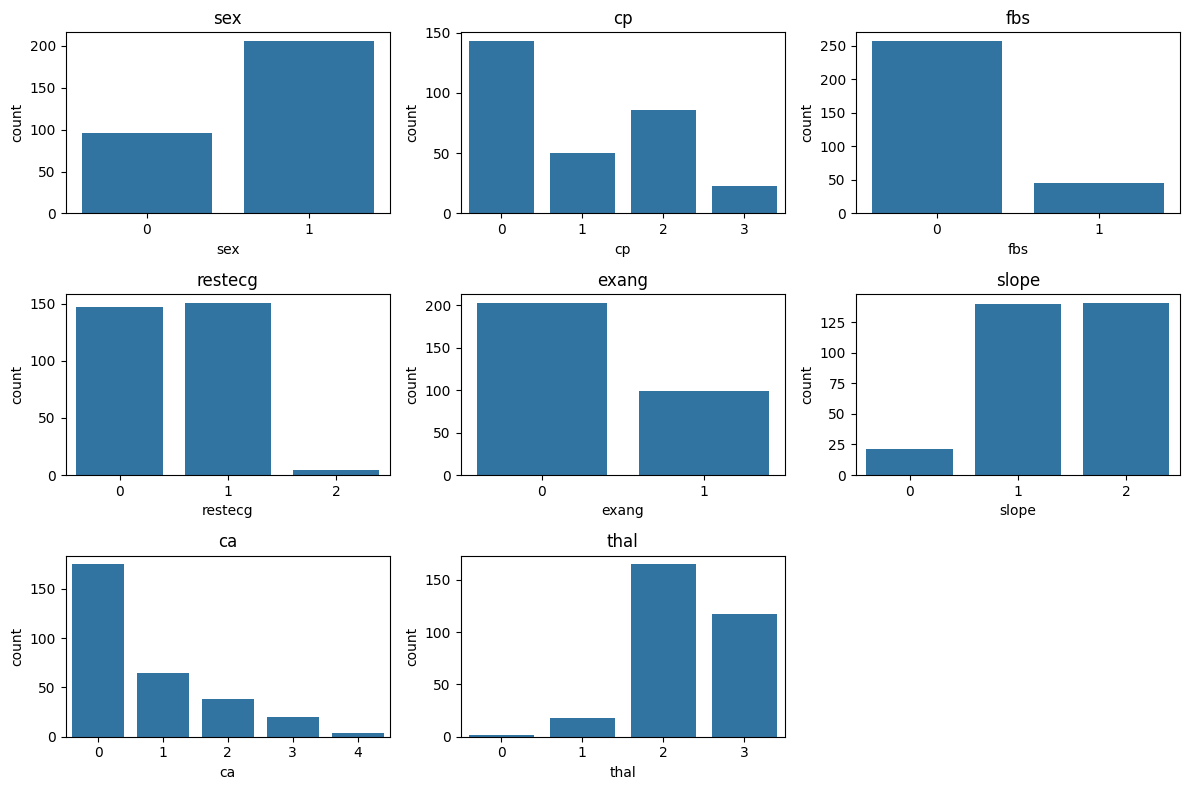

In [45]:
cat_col = ['sex','cp','fbs','restecg','exang','slope','ca','thal']

plt.figure(figsize=(12,8))

for i, col in enumerate(cat_col,1):
    plt.subplot(3,3,i)
    sns.countplot(data=data, x=col)
    plt.title(col)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Features correation Heatmap')

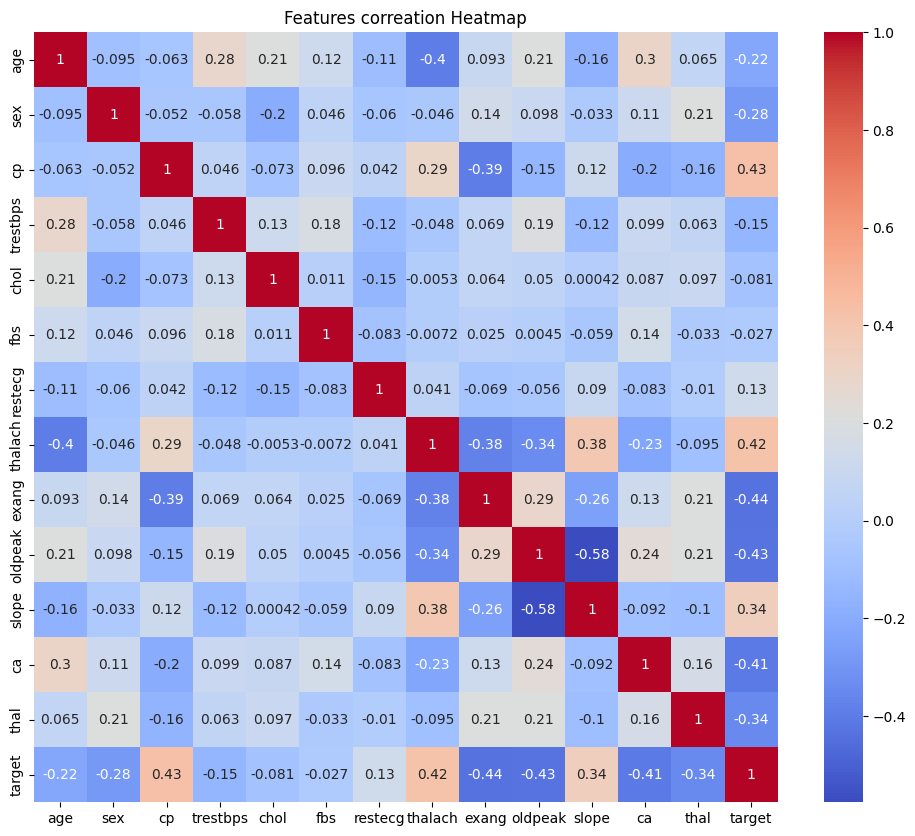

In [46]:
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(),annot=True,cmap='coolwarm')
plt.title("Features correation Heatmap")

In [47]:
x = data.drop(columns='target',axis=1)
y = data['target']

In [48]:
print(x.shape)
print(y.shape)

(302, 13)
(302,)


In [49]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [50]:
scaler = MinMaxScaler()

In [51]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [52]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [53]:
def evaluate_model(model,x_train,x_test,y_train,y_test):
    y_pred = model.predict(x_test)
    ac = accuracy_score(y_test,y_pred)
    pre = precision_score(y_test,y_pred)
    re = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    print(classification_report(y_test,y_pred))
    print(confusion_matrix(y_test,y_pred))
    return {"Accuracy Score" : ac, "Precision Score" : pre, "recall Score" : re,"f1 Score":f1}

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

results = {}

# ---------------- Logistic Regression ----------------

lr = LogisticRegression(max_iter=1000)

lr.fit(x_train, y_train)

results["Logistic Regression"] = evaluate_model(
    lr, x_train, x_test, y_train, y_test
)

print("Logistic Regression model trained")


# ---------------- Random Forest Classifier ----------------

rf = RandomForestClassifier()

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=0
)

rf_grid.fit(x_train, y_train)

best_rf = rf_grid.best_estimator_

results["Random Forest Classifier"] = evaluate_model(
    best_rf, x_train, x_test, y_train, y_test
)

print("Random Forest Training completed, best parameters:", rf_grid.best_params_)


# ---------------- KNN Classifier ----------------

best_k = 0
best_score = 0

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    score = accuracy_score(y_test, y_pred)

    if score > best_score:
        best_score = score
        best_k = k

print("Best K Value:", best_k)
print("Best Accuracy:", best_score)

# Final Model with Best K
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(x_train, y_train)

results["KNeighbors Classifier"] = evaluate_model(
    final_model, x_train, x_test, y_train, y_test
)

print("\nKNeighbors Classifier training completed with:", best_k, "neighbors")


# ---------------- Decision Tree Classifier ----------------

dt = DecisionTreeClassifier()

dt_params = {
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

dt_grid = GridSearchCV(
    dt,
    dt_params,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=0
)

dt_grid.fit(x_train, y_train)

best_dt = dt_grid.best_estimator_

results["Decision Tree Classifier"] = evaluate_model(
    best_dt,
    x_train,
    x_test,
    y_train,
    y_test
)

print("Decision Tree Training completed, best parameters:", dt_grid.best_params_)

              precision    recall  f1-score   support

           0       0.88      0.69      0.77        32
           1       0.72      0.90      0.80        29

    accuracy                           0.79        61
   macro avg       0.80      0.79      0.79        61
weighted avg       0.80      0.79      0.79        61

[[22 10]
 [ 3 26]]
Logistic Regression model trained
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        32
           1       0.79      0.90      0.84        29

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61

[[25  7]
 [ 3 26]]
Random Forest Training completed, best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best K Value: 10
Best Accuracy: 0.8524590163934426
              precision    recall  f1-score   support

           0       0.93      

In [55]:
results

{'Logistic Regression': {'Accuracy Score': 0.7868852459016393,
  'Precision Score': 0.7222222222222222,
  'recall Score': 0.896551724137931,
  'f1 Score': 0.8},
 'Random Forest Classifier': {'Accuracy Score': 0.8360655737704918,
  'Precision Score': 0.7878787878787878,
  'recall Score': 0.896551724137931,
  'f1 Score': 0.8387096774193549},
 'KNeighbors Classifier': {'Accuracy Score': 0.8524590163934426,
  'Precision Score': 0.7941176470588235,
  'recall Score': 0.9310344827586207,
  'f1 Score': 0.8571428571428571},
 'Decision Tree Classifier': {'Accuracy Score': 0.7213114754098361,
  'Precision Score': 0.75,
  'recall Score': 0.6206896551724138,
  'f1 Score': 0.6792452830188679}}

In [56]:
results_df = pd.DataFrame(results).T.sort_values(by='Accuracy Score', ascending=False)
results_df

,Accuracy Score,Precision Score,recall Score,f1 Score
KNeighbors Classifier,0.852459,0.794118,0.931034,0.857143
Random Forest Classifier,0.836066,0.787879,0.896552,0.838710
Logistic Regression,0.786885,0.722222,0.896552,0.800000
Decision Tree Classifier,0.721311,0.750000,0.620690,0.679245


In [57]:
models = {
    'Logistic Regression':lr,
    'Random Forest Classifier':best_rf,
    'KNeighbors Classifier':final_model,
    'Decision Tree Classifier':best_dt
}

In [58]:
best_Accuracy_score = results_df["Accuracy Score"].max()
best_Accuracy_score

np.float64(0.8524590163934426)

In [59]:
top_model = results_df[results_df['Accuracy Score'] == best_Accuracy_score]
top_model

,Accuracy Score,Precision Score,recall Score,f1 Score
KNeighbors Classifier,0.852459,0.794118,0.931034,0.857143


In [60]:
best_model = models[top_model.index[0]]

In [61]:
best_model

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [62]:
joblib.dump(best_model,"best_model.pkl")

['best_model.pkl']